CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 39.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.61MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model=myCNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

모델 학습 ✅

In [26]:
train_losses = []
n = len(train_loader)

model.train()
LOSS_sum = 0

for images, labels  in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    LOSS_sum += loss.item()
    optimizer.step()
train_losses.append(LOSS_sum/n)

In [27]:
train_losses[0]

0.015462849946435181

모델 평가 ✅

In [42]:
# 3. 모델 평가
model.eval()

n = len(test_loader)
correct = 0
total = 0
test_loss = 0
test_losses = []
accuracy = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().float()

    test_losses.append(test_loss/n)
    accuracy.append(100 * correct / total)

print("Test Loss:", test_losses[0])
print("Accuracy of Test Data:", accuracy[0].item())

Test Loss: 0.03297370949294418
Accuracy of Test Data: 99.30000305175781


10회 반복 시행 ✅

In [43]:
epoch = 10

train_losses = []
test_losses = []
accuracy = []

for i in range(epoch):
    model.train()
    LOSS_sum = 0

    for images, labels  in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        LOSS_sum += loss.item() * len(images)
        optimizer.step()
    train_losses.append(LOSS_sum/(len(train_dataset)))

    # 3. 모델 평가
    model.eval()

    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().float()

        test_losses.append(test_loss/(len(test_loader)))
        accuracy.append(100 * correct / total)

    print(f"Epoch {i+1} : ")
    print(f"Test Loss: {test_losses[-1]:.4f}")
    print(f"Test accuracy: {accuracy[-1].item():.4f}")

Epoch 1 : 
Test Loss: 0.0351
Test accuracy: 99.1500
Epoch 2 : 
Test Loss: 0.0373
Test accuracy: 99.1600
Epoch 3 : 
Test Loss: 0.0369
Test accuracy: 99.2800
Epoch 4 : 
Test Loss: 0.0368
Test accuracy: 99.1900
Epoch 5 : 
Test Loss: 0.0484
Test accuracy: 99.1000
Epoch 6 : 
Test Loss: 0.0414
Test accuracy: 99.2600
Epoch 7 : 
Test Loss: 0.0672
Test accuracy: 98.8800
Epoch 8 : 
Test Loss: 0.0713
Test accuracy: 98.8100
Epoch 9 : 
Test Loss: 0.0413
Test accuracy: 99.2500
Epoch 10 : 
Test Loss: 0.0508
Test accuracy: 99.1000


결과 시각화

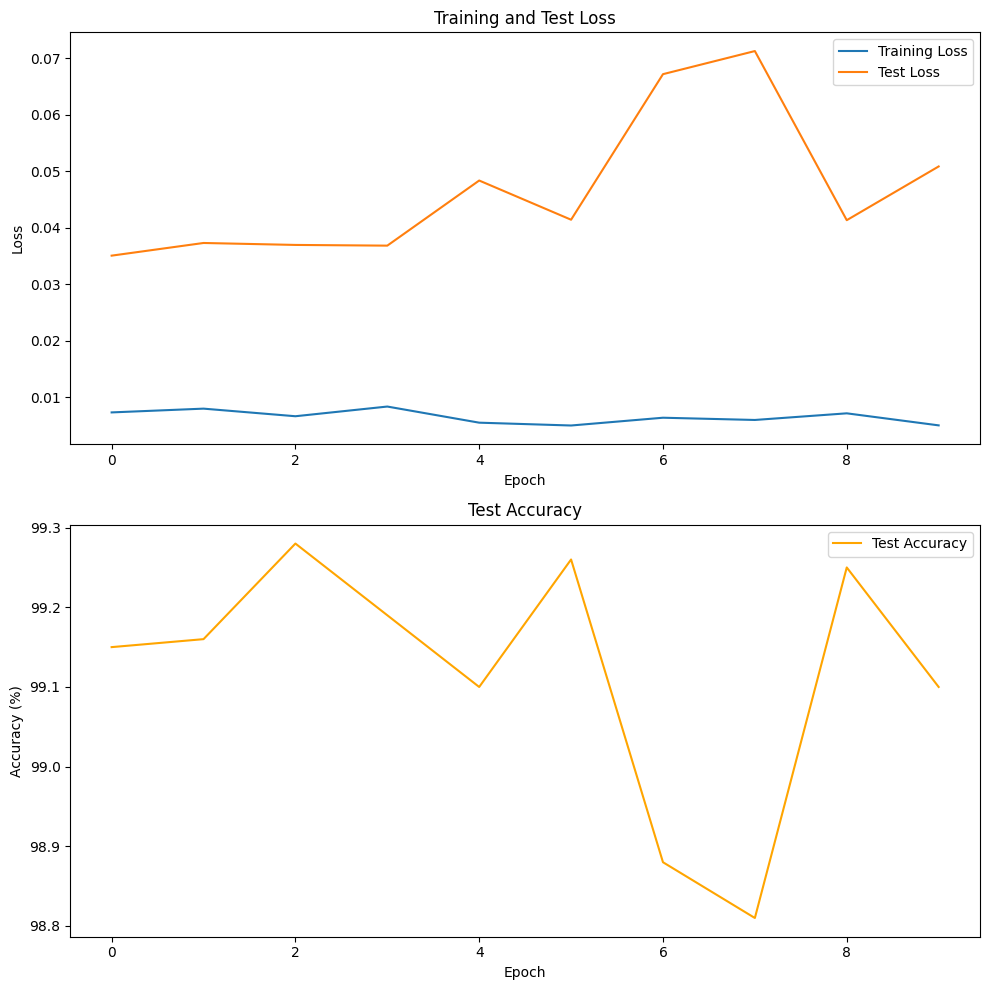

In [44]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(accuracy, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()